In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
df_original = pd.read_csv('Algerian_forest_fires_dataset_cleaned.csv')

In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   243 non-null    int64  
 1   day          243 non-null    int64  
 2   month        243 non-null    int64  
 3   year         243 non-null    int64  
 4   Temperature  243 non-null    int64  
 5   RH           243 non-null    int64  
 6   Ws           243 non-null    int64  
 7   Rain         243 non-null    float64
 8   FFMC         243 non-null    float64
 9   DMC          243 non-null    float64
 10  DC           243 non-null    float64
 11  ISI          243 non-null    float64
 12  BUI          243 non-null    float64
 13  FWI          243 non-null    float64
 14  Classes      243 non-null    object 
 15  Region       243 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.5+ KB


In [4]:
df = df_original
df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
df = df.drop(columns=['day','month','year'])

In [6]:
df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [8]:
df['Classes'] = df['Classes'].str.strip()

In [9]:
df['Classes'] = np.where(df['Classes'] == 'not fire',0,1)

In [10]:
df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [11]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [12]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [13]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Classes'}>,
        <Axes: title={'center': 'Region'}>]], dtype=object)

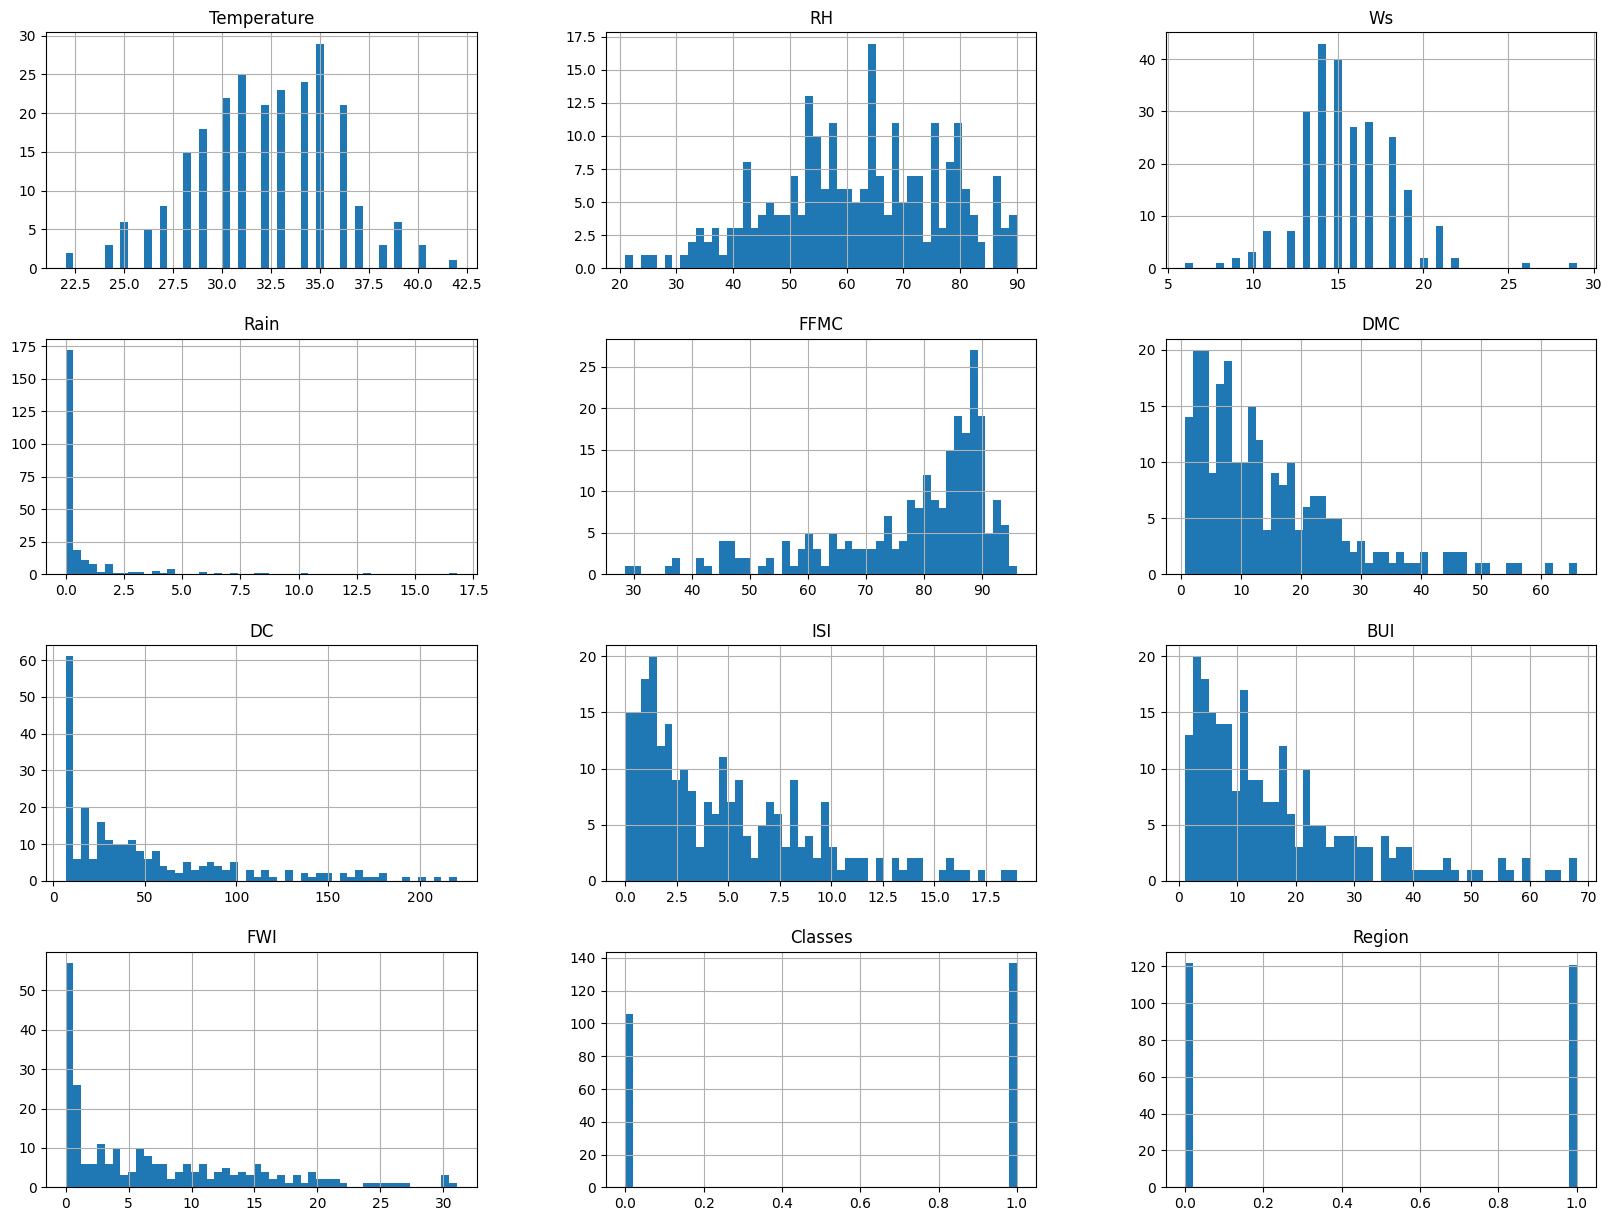

In [14]:

df.hist(bins= 50,figsize=(20,15))

<Axes: >

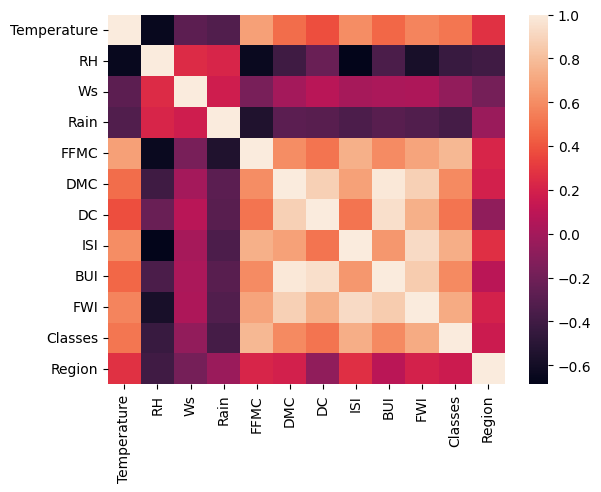

In [15]:
sns.heatmap(df.corr())

<Axes: ylabel='FWI'>

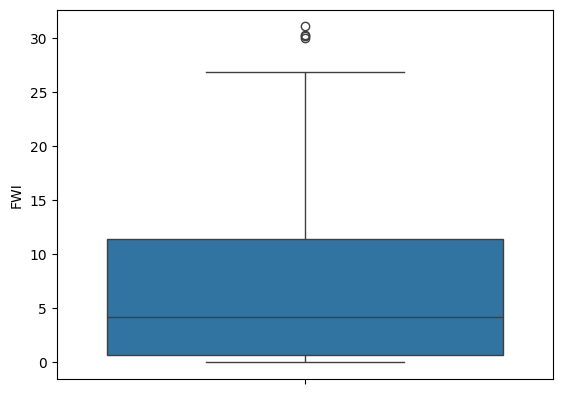

In [16]:
sns.boxplot(df['FWI'])


In [17]:
df['month'] = df_original['month']

Text(0.5, 1.0, 'Fire Analysis of Sidi- Bel Regions')

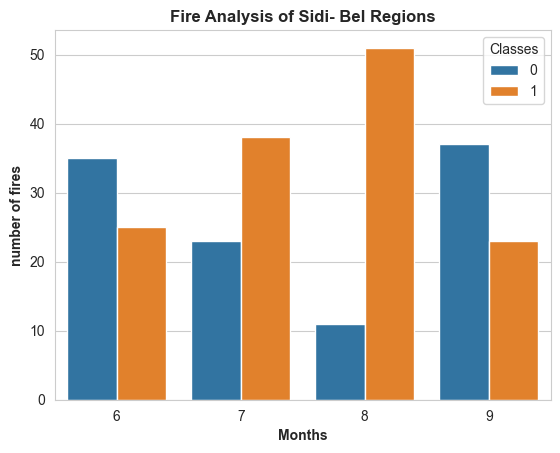

In [18]:
dftemp = df.loc[df['Region'] == 1]
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data= df)
plt.xlabel("Months",weight= 'bold')
plt.ylabel('number of fires',weight= 'bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Brjaia Regions')

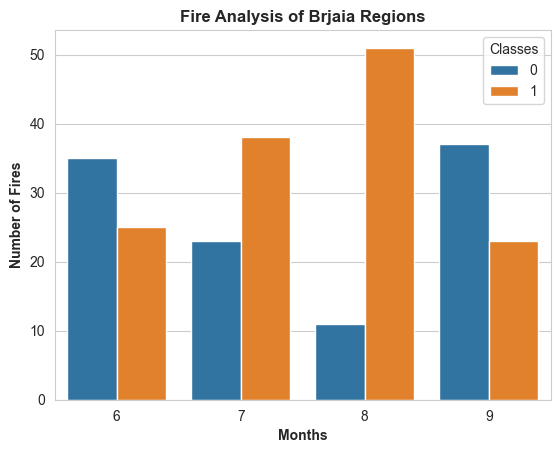

In [19]:
dftemp=df.loc[df['Region']==0]
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')

### Feature Selection

In [20]:
X = df.drop('FWI', axis=1)
y = df['FWI']

In [21]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region,month
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0,6
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0,6
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0,6
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0,6
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0,6


In [22]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [23]:
#Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state= 42)

In [24]:
X_train.shape, X_test.shape

((182, 12), (61, 12))

In [25]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region,month
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549,-0.015272
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665,-0.031036
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969,-0.037508
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022,0.008632
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514,-0.006620
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582,0.053308
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838,0.121493
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441,0.076010
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897,0.074529
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837,0.005476


<Axes: >

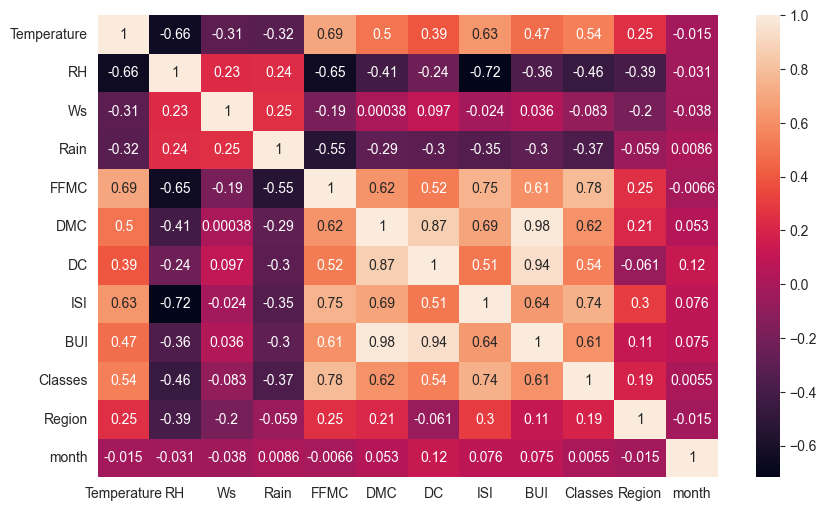

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.corr(),annot=True)

In [27]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) >= threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    
    return col_corr

In [28]:
corr_features = correlation(X_train,0.85)

In [29]:
X_train.drop(corr_features, axis=1, inplace= True)
X_test.drop(corr_features, axis=1, inplace= True)

In [30]:
X_train.shape

(182, 10)

### Feature Selection or preprocessing

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [32]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -1.10431526,
        -0.98907071,  1.3585682 ],
       [-0.30175842,  0.64950844, -0.59874754, ..., -1.10431526,
         1.01105006, -1.34865164],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  0.90553851,
         1.01105006,  0.45616158],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.10431526,
        -0.98907071,  1.3585682 ],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.90553851,
         1.01105006, -0.44624503],
       [-0.57230045,  0.98343651,  2.05910739, ..., -1.10431526,
        -0.98907071,  1.3585682 ]], shape=(182, 10))

Text(0.5, 1.0, 'After Scaling')

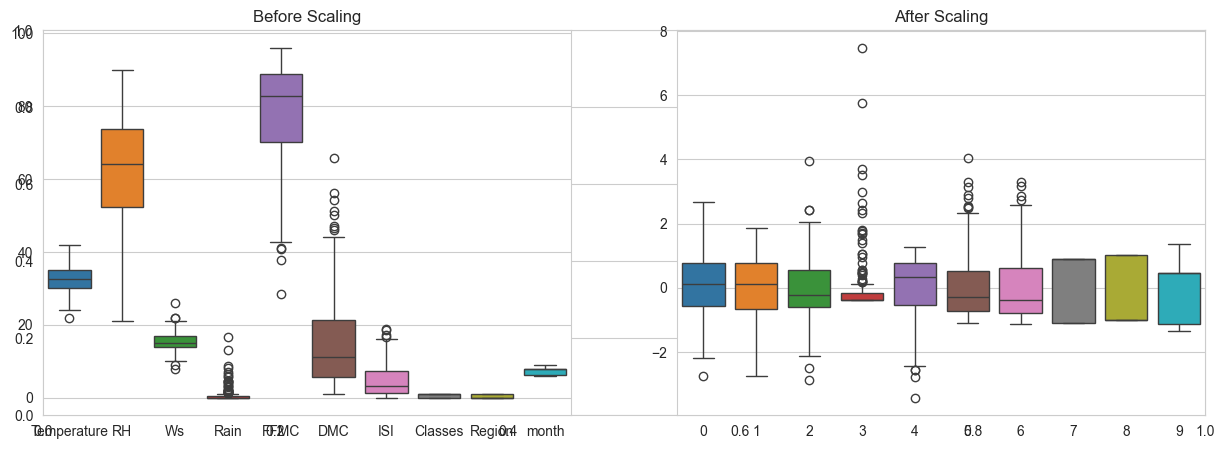

In [33]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("After Scaling")


### Linear Regression Model


mean absolute error=  1.004483293723777
r2 square=  0.9603471598983763


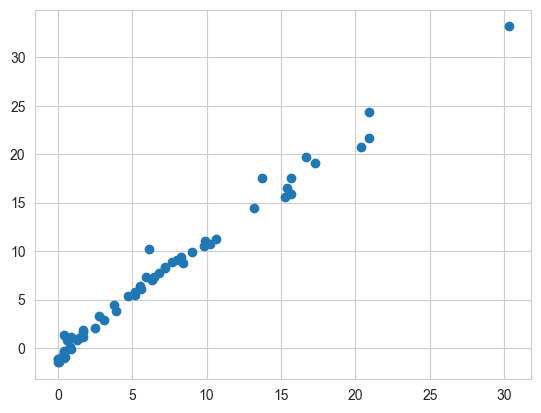

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)

y_pred = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

### Lasso


mean absolute error=  0.9605020166901075
r2 square=  0.9692970913627958


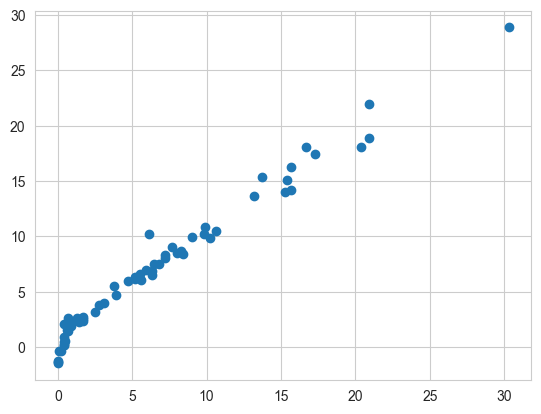

In [35]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

lasso = Lasso()
lasso.fit(X_train_scaled,y_train)

y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

### Ridge

mean absolute error=  0.998844315444697
r2 square=  0.9611824467133324


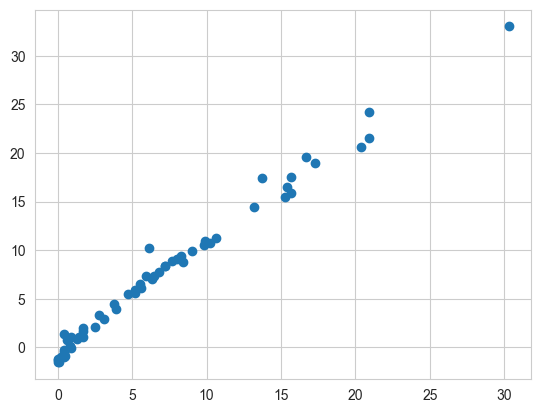

In [36]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

ridge = Ridge()
ridge.fit(X_train_scaled,y_train)

y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

mean absolute error=  1.6511868138541963
r2 square=  0.9081702005009653


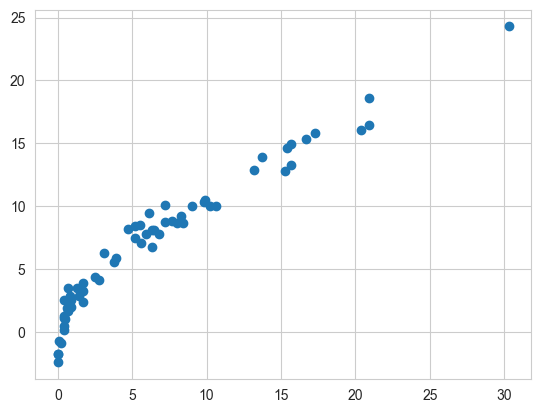

In [37]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

elasticNet = ElasticNet()
elasticNet.fit(X_train_scaled,y_train)

y_pred = elasticNet.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

### Cross Validation using lasso

mean absolute error=  0.9756633665530328
r2 square=  0.9608583497831737


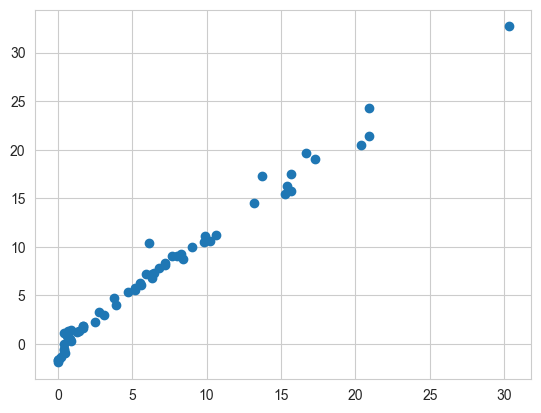

In [38]:
from sklearn.linear_model import LassoCV

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled,y_train)

y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)


mean absolute error=  0.9988443154420849
r2 square=  0.9611824467135001


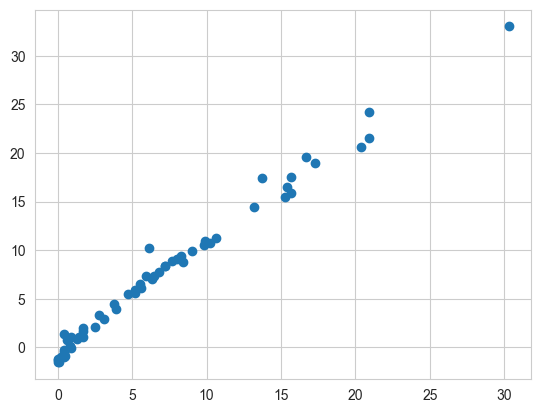

In [39]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

ridgecv = RidgeCV()
ridgecv.fit(X_train_scaled,y_train)

y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

mean absolute error=  0.9831880720441936
r2 square=  0.9627683519668383


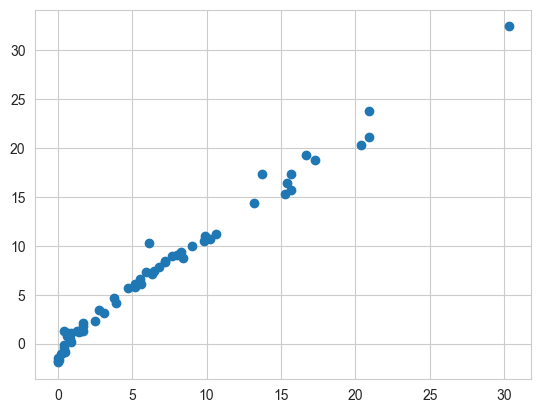

In [40]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaled,y_train)

y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error= ", mae)
print("r2 square= ", score)
plt.scatter(y_test,y_pred)

In [42]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))